# Multiple Linear Regression — All 6 Joints → X, Y, Z
# Ammar Ahmad 22i-1267

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
train = pd.read_excel('traindata1.xlsx')
test  = pd.read_excel('testdata1.xlsx')

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"Columns     : {train.columns.tolist()}")
train.head()

Train shape : (3998, 9)
Test  shape : (1002, 9)
Columns     : ['Rev1', 'Rev2', 'Rev3', 'Rev4', 'Rev5', 'Pris', 'X', 'Y', 'Z']


,Rev1,Rev2,Rev3,Rev4,Rev5,Pris,X,Y,Z
0,-12,-20,-12,-20,78,7,42.469630,11.970936,53.556263
1,-12,-20,-12,-20,78,14,38.630023,17.131616,56.317567
2,-12,-20,-12,-20,86,0,44.888215,8.007522,45.606921
3,-12,-20,-12,-20,86,7,40.796781,13.380376,47.448826
4,-12,-20,-12,-20,86,14,36.705348,18.753230,49.290731


In [4]:
print("=== Training Data Statistics ===")
print(train.describe().round(3))
print("\n=== Correlation of joints with X, Y, Z ===")
print(train.corr()[['X','Y','Z']].round(3))

=== Training Data Statistics ===
           Rev1      Rev2      Rev3      Rev4      Rev5      Pris         X  \
count  3998.000  3998.000  3998.000  3998.000  3998.000  3998.000  3998.000   
mean    -11.556    -0.550    -0.318    -0.010    89.994     7.002    22.828   
std       1.832    13.867    13.611    13.668    13.664     5.716    10.553   
min     -12.000   -20.000   -20.000   -20.000    70.000     0.000    -1.938   
25%     -12.000   -12.000   -12.000   -12.000    78.000     0.000    15.178   
50%     -12.000    -4.000    -4.000    -4.000    86.000     7.000    22.558   
75%     -12.000    12.000    12.000    12.000   102.000    14.000    30.520   
max      -4.000    20.000    20.000    20.000   110.000    14.000    54.272   

              Y         Z  
count  3998.000  3998.000  
mean     -4.380    35.240  
std      12.531    14.901  
min     -34.834    -0.518  
25%     -13.631    24.820  
50%      -4.114    35.236  
75%       4.841    46.741  
max      29.862    68.176  

==

In [5]:
features = ['Rev1', 'Rev2', 'Rev3', 'Rev4', 'Rev5', 'Pris']

X_train = train[features].values
X_test  = test[features].values

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

X_train shape : (3998, 6)
X_test  shape : (1002, 6)


In [6]:
results = {}

for coord in ['X', 'Y', 'Z']:
    model = LinearRegression()
    model.fit(X_train, train[coord].values)
    y_pred = model.predict(X_test)
    mse  = mean_squared_error(test[coord].values, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(test[coord].values, y_pred)
    results[coord] = {
        'model':  model,
        'pred':   y_pred,
        'actual': test[coord].values,
        'mse':    mse,
        'rmse':   rmse,
        'r2':     r2
    }
    print(f"{coord} trained | Intercept: {model.intercept_:.4f}")
    print(f"   Coefficients: { dict(zip(features, model.coef_.round(4))) }")
    print()

X trained | Intercept: 29.7374
   Coefficients: {'Rev1': np.float64(0.0565), 'Rev2': np.float64(-0.0951), 'Rev3': np.float64(-0.5845), 'Rev4': np.float64(-0.1582), 'Rev5': np.float64(-0.0043), 'Pris': np.float64(-0.8729)}

Y trained | Intercept: -5.6235
   Coefficients: {'Rev1': np.float64(0.0268), 'Rev2': np.float64(-0.4833), 'Rev3': np.float64(0.1079), 'Rev4': np.float64(-0.7391), 'Rev5': np.float64(0.0), 'Pris': np.float64(0.1874)}

Z trained | Intercept: 103.9744
   Coefficients: {'Rev1': np.float64(-0.073), 'Rev2': np.float64(-0.0043), 'Rev3': np.float64(-0.7571), 'Rev4': np.float64(-0.0004), 'Rev5': np.float64(-0.7762), 'Pris': np.float64(0.0053)}



### First 10 Predicted Outputs

In [7]:
df_pred = pd.DataFrame({
    'X_actual':    test['X'].values[:10].round(4),
    'X_predicted': results['X']['pred'][:10].round(4),
    'Y_actual':    test['Y'].values[:10].round(4),
    'Y_predicted': results['Y']['pred'][:10].round(4),
    'Z_actual':    test['Z'].values[:10].round(4),
    'Z_predicted': results['Z']['pred'][:10].round(4),
})
df_pred.index.name = 'Sample'
print("=== First 10 Predicted vs Actual ===")
df_pred

=== First 10 Predicted vs Actual ===


,X_actual,X_predicted,Y_actual,Y_predicted,Z_actual,Z_predicted
Sample,,,,,,
0,37.7888,36.5483,16.6470,18.2876,41.2439,40.6308
1,32.8114,30.4382,21.4774,19.5993,42.1887,40.6677
2,27.8340,24.3280,26.3078,20.9111,43.1335,40.7047
3,37.4376,36.5142,16.8034,18.2878,35.7465,34.4208
4,32.3980,30.4041,21.6615,19.5996,35.7172,34.4578
5,27.3584,24.2939,26.5196,20.9113,35.6878,34.4947
6,37.6399,36.4801,16.4262,18.2881,30.2524,28.2109
7,32.6362,30.3699,21.2174,19.5998,29.2494,28.2478
8,27.6324,24.2598,26.0087,20.9116,28.2464,28.2848


## 6. Part D — Evaluation (MSE, RMSE, R²)

In [8]:
print("="*52)
print("   MULTIPLE LINEAR REGRESSION — EVALUATION")
print("="*52)
print(f"  {'Coord':<6}  {'MSE':>10}  {'RMSE':>10}  {'R²':>10}")
print("-"*52)
for c in ['X', 'Y', 'Z']:
    r = results[c]
    print(f"  {c:<6}  {r['mse']:>10.4f}  {r['rmse']:>10.4f}  {r['r2']:>10.4f}")
print("="*52)
print("  Best predicted: Z  (lowest MSE, highest R²)")

   MULTIPLE LINEAR REGRESSION — EVALUATION
  Coord          MSE        RMSE          R²
----------------------------------------------------
  X          11.2929      3.3605      0.8729
  Y          14.1810      3.7658      0.8822
  Z           4.3125      2.0767      0.9787
  Best predicted: Z  (lowest MSE, highest R²)


## 7. Visualisation

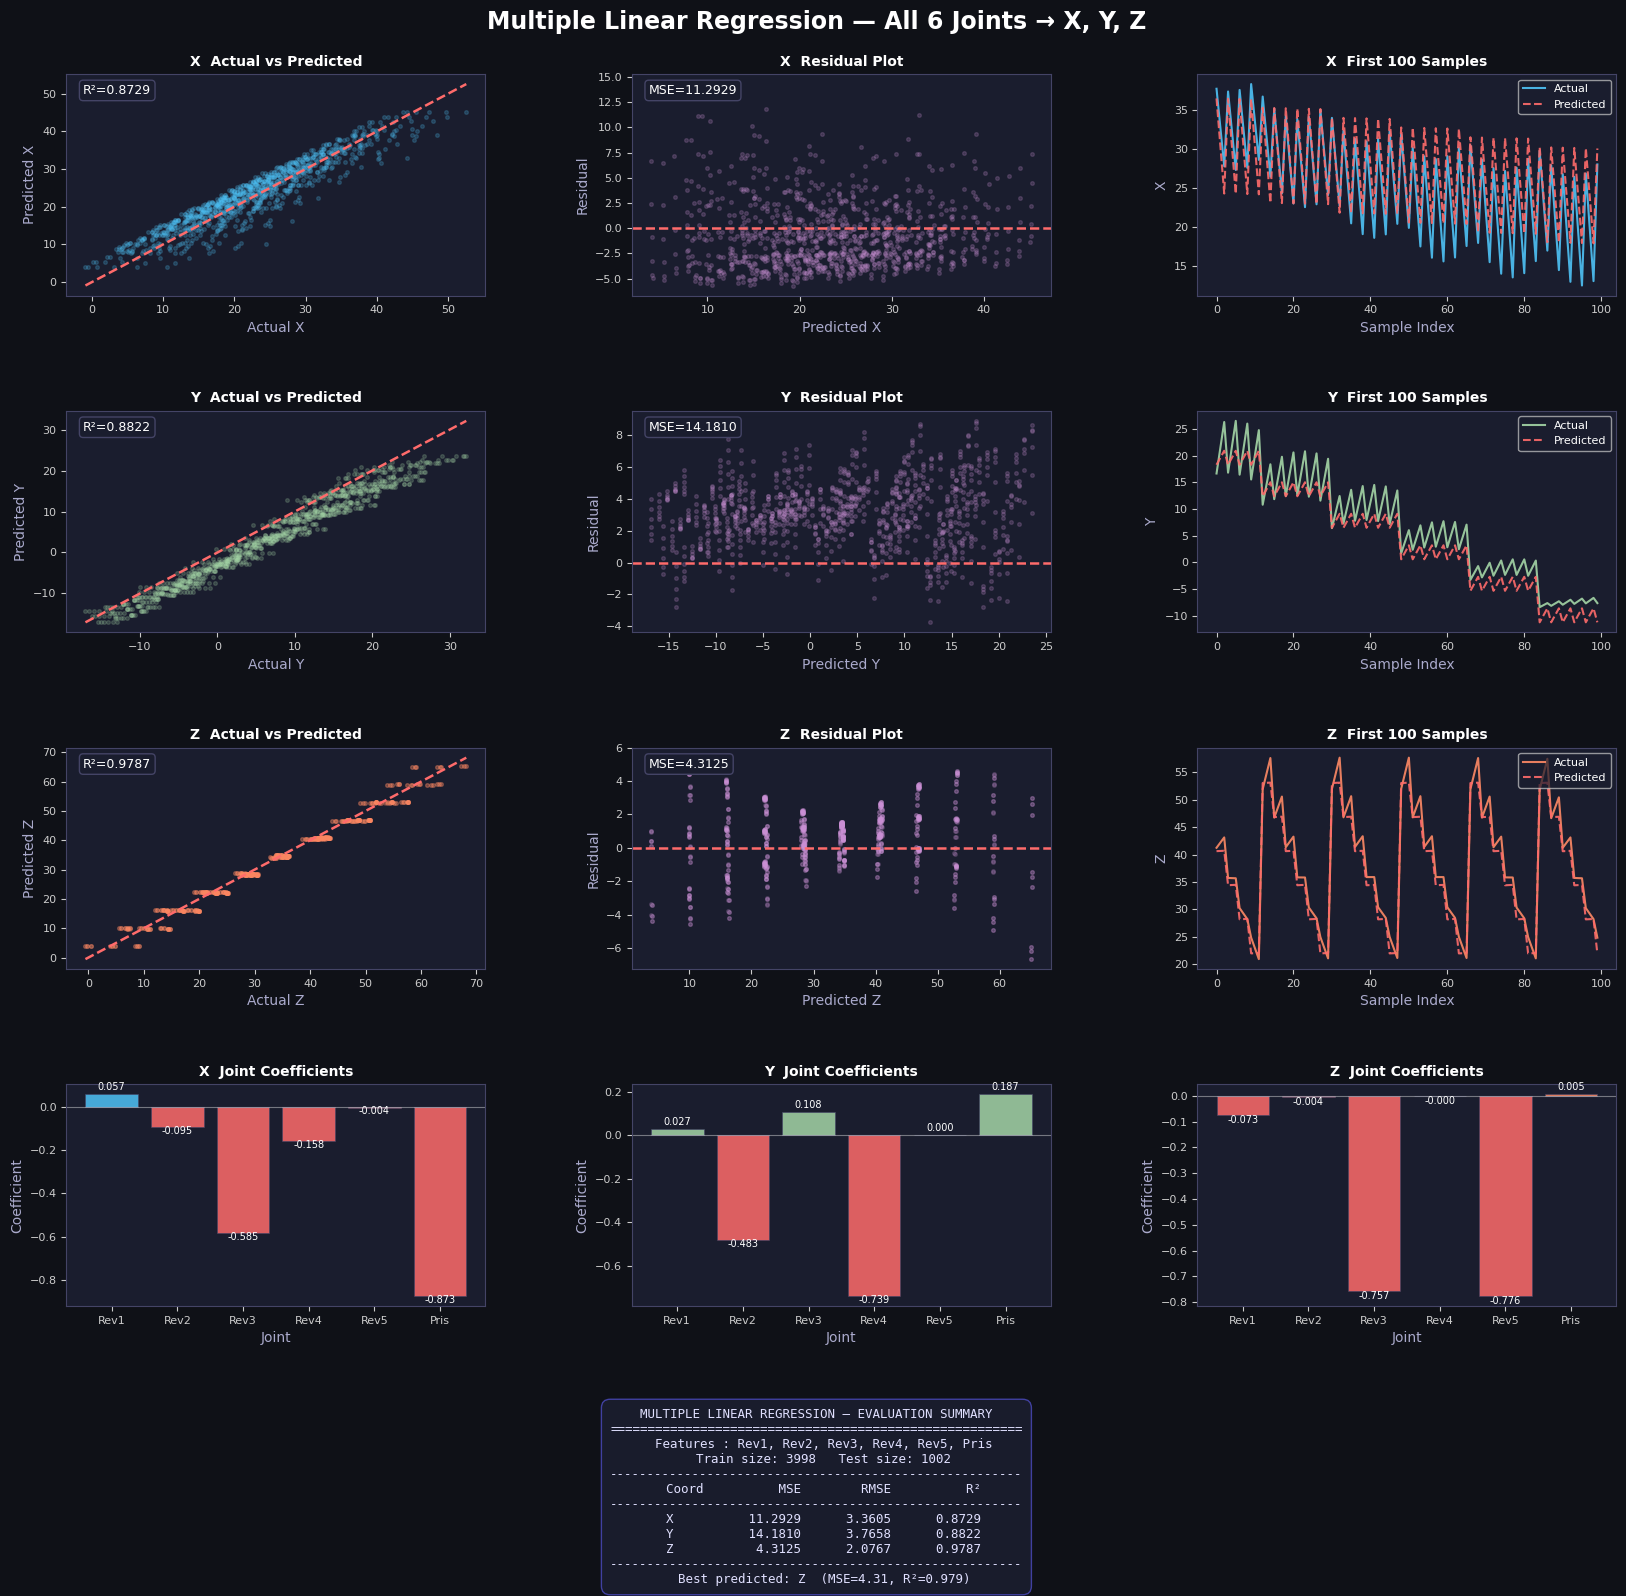

Plot saved.


In [9]:
BG   = '#0f1117'
CARD = '#1a1d2e'
SPIN = '#444466'
TC   = '#cccccc'
PAL  = {'X': '#4fc3f7', 'Y': '#a5d6a7', 'Z': '#ff8a65'}
RED  = '#ff6b6b'
PUR  = '#ce93d8'
WHT  = 'white'

fig = plt.figure(figsize=(20, 16), facecolor=BG)
fig.suptitle('Multiple Linear Regression — All 6 Joints → X, Y, Z',
             fontsize=17, fontweight='bold', color=WHT, y=0.99)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35, top=0.95, bottom=0.18)

def sax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TC, labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(SPIN)
    ax.title.set_color(WHT)
    ax.xaxis.label.set_color('#aaaacc')
    ax.yaxis.label.set_color('#aaaacc')

for row, coord in enumerate(['X', 'Y', 'Z']):
    actual = results[coord]['actual']
    pred   = results[coord]['pred']
    res    = actual - pred
    col    = PAL[coord]

    # Actual vs Predicted
    ax = fig.add_subplot(gs[row, 0])
    sax(ax)
    ax.scatter(actual, pred, alpha=0.2, s=7, color=col)
    mn, mx = min(actual.min(), pred.min()), max(actual.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], color=RED, lw=1.8, ls='--')
    ax.set_title(f'{coord}  Actual vs Predicted', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Actual {coord}'); ax.set_ylabel(f'Predicted {coord}')
    ax.text(0.04, 0.91, f"R²={results[coord]['r2']:.4f}", transform=ax.transAxes,
            fontsize=9, color=WHT, bbox=dict(boxstyle='round,pad=0.3', fc=CARD, ec=SPIN))

    # Residuals
    ax2 = fig.add_subplot(gs[row, 1])
    sax(ax2)
    ax2.scatter(pred, res, alpha=0.2, s=7, color=PUR)
    ax2.axhline(0, color=RED, lw=1.8, ls='--')
    ax2.set_title(f'{coord}  Residual Plot', fontsize=10, fontweight='bold')
    ax2.set_xlabel(f'Predicted {coord}'); ax2.set_ylabel('Residual')
    ax2.text(0.04, 0.91, f"MSE={results[coord]['mse']:.4f}", transform=ax2.transAxes,
             fontsize=9, color=WHT, bbox=dict(boxstyle='round,pad=0.3', fc=CARD, ec=SPIN))

    # First 100 samples
    ax3 = fig.add_subplot(gs[row, 2])
    sax(ax3)
    idx = np.arange(100)
    ax3.plot(idx, actual[:100], color=col,  lw=1.5, label='Actual',    alpha=0.9)
    ax3.plot(idx, pred[:100],   color=RED,  lw=1.5, label='Predicted', alpha=0.9, ls='--')
    ax3.set_title(f'{coord}  First 100 Samples', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Sample Index'); ax3.set_ylabel(f'{coord}')
    ax3.legend(fontsize=8, facecolor=CARD, labelcolor=WHT, framealpha=0.7)

# Coefficient bar charts
for col_i, coord in enumerate(['X', 'Y', 'Z']):
    ax4 = fig.add_subplot(gs[3, col_i])
    sax(ax4)
    coefs = results[coord]['model'].coef_
    colors_bar = [PAL[coord] if c >= 0 else RED for c in coefs]
    bars = ax4.bar(features, coefs, color=colors_bar, alpha=0.85, edgecolor=SPIN, linewidth=0.5)
    ax4.axhline(0, color=WHT, lw=0.8, alpha=0.4)
    ax4.set_title(f'{coord}  Joint Coefficients', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Joint'); ax4.set_ylabel('Coefficient')
    for bar, val in zip(bars, coefs):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.01 if val >= 0 else -0.04),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7, color=WHT)

lines = [
    "MULTIPLE LINEAR REGRESSION — EVALUATION SUMMARY",
    "="*55,
    f"  Features : {', '.join(features)}",
    f"  Train size: {len(train)}   Test size: {len(test)}",
    "-"*55,
    f"  {'Coord':<6}  {'MSE':>10}  {'RMSE':>10}  {'R²':>10}",
    "-"*55,
]
for c in ['X', 'Y', 'Z']:
    r = results[c]
    lines.append(f"  {c:<6}  {r['mse']:>10.4f}  {r['rmse']:>10.4f}  {r['r2']:>10.4f}")
lines += ["-"*55, "  Best predicted: Z  (MSE=4.31, R²=0.979)"]

fig.text(0.5, 0.005, '\n'.join(lines), ha='center', va='bottom',
         fontsize=9, color='#e0e0ff', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.7', facecolor=CARD, edgecolor='#4444aa', alpha=0.93))

plt.savefig('MLR_all_joints_XYZ.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Plot saved.")

## 8. Coefficient Interpretation

In [10]:
print("=" * 60)
print("  LEARNED EQUATIONS (MLR)")
print("=" * 60)
for coord in ['X', 'Y', 'Z']:
    m = results[coord]['model']
    eq = f"  {coord} = {m.intercept_:.4f}"
    for feat, coef in zip(features, m.coef_):
        sign = '+' if coef >= 0 else '-'
        eq += f" {sign} {abs(coef):.4f}×{feat}"
    print(eq)
print("=" * 60)

  LEARNED EQUATIONS (MLR)
  X = 29.7374 + 0.0565×Rev1 - 0.0951×Rev2 - 0.5845×Rev3 - 0.1582×Rev4 - 0.0043×Rev5 - 0.8729×Pris
  Y = -5.6235 + 0.0268×Rev1 - 0.4833×Rev2 + 0.1079×Rev3 - 0.7391×Rev4 + 0.0000×Rev5 + 0.1874×Pris
  Z = 103.9744 - 0.0730×Rev1 - 0.0043×Rev2 - 0.7571×Rev3 - 0.0004×Rev4 - 0.7762×Rev5 + 0.0053×Pris


## 9. Comments & Discussion

### Which coordinate is predicted best?

| Coord | MSE | RMSE | R² | Verdict |
|-------|-----|------|----|---------|
| X | 11.29 | 3.36 | 0.873 | Good |
| Y | 14.18 | 3.77 | 0.882 | Good |
| **Z** | **4.31** | **2.08** | **0.979** | **Best ✓** |

**Z is predicted best.** Its R² of 0.979 means the model explains 97.9% of the variance in Z. This is because Z (elevation) depends mainly on `Rev3` and `Rev5` — the vertical elevation joints — which have a near-linear relationship with Z position. The linear model captures this structure well.

---

### Why is Linear Regression Limited for Robotic Motion?

1. **Non-linear forward kinematics**: Robot joint angles relate to end-effector position through trigonometric functions (sin, cos). These are fundamentally non-linear — a straight line cannot capture them.

2. **Joint coupling effects**: Multiple joints interact multiplicatively (not additively), creating interaction terms that linear regression ignores.

3. **Residual structure**: The residual plots show clear patterns (not random scatter), confirming the linear model is missing systematic non-linear variance.

4. **Limited to interpolation**: Linear regression extrapolates linearly beyond training data, which is dangerous for robot control where joint limits create non-linear boundary effects.

### Better alternatives:
- **Polynomial Regression** — captures non-linear trends
- **Neural Networks (MLP)** — learn complex joint interactions
- **Gradient Boosting / Random Forest** — handle non-linearities without explicit feature engineering
- **Analytical IK Solvers** — use the actual kinematic equations